In [3]:
import numpy as np
import random
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPool2D, Flatten, Dense
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
import tensorflow as tf

In [4]:
X_train = np.loadtxt("./data/input.csv", delimiter = ",")
Y_train = np.loadtxt("./data/labels.csv", delimiter = ",")

X_test = np.loadtxt("./data/input_test.csv", delimiter = ",")
Y_test = np.loadtxt("./data/labels_test.csv", delimiter = ",")

In [12]:
X_train = X_train.reshape(len(X_train), 100, 100,3)
Y_train = Y_train.reshape(len(Y_train), 1)

X_test = X_test.reshape(len(X_test), 100, 100, 3)
Y_test = Y_test.reshape(len(Y_test), 1)

X_train = X_train / 255.0
X_test = X_test / 255.0

datagen = ImageDataGenerator(
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.3,
    horizontal_flip=True,
    vertical_flip=True,
    fill_mode="nearest",
    validation_split=0.2  # Validation için %20 ayır
)

In [7]:
model = Sequential([
    Conv2D(32, (3,3), activation = "relu", input_shape = (100,100,3)),
    MaxPool2D((2,2)),

    Conv2D(32, (3,3), activation="relu"),
    MaxPool2D((2,2)),

    Flatten(),
    Dense(64, activation="relu"),
    Dense(1, activation="sigmoid")
])

model = Sequential()

model.add(Conv2D(64, (3,3), activation= "relu", input_shape = (100, 100, 3)))
model.add(MaxPool2D((2,2)))

model.add(Conv2D(64, (3,3), activation= "relu", ))
model.add(MaxPool2D((2,2)))

model.add(Conv2D(64, (3,3), activation= "elu", ))
model.add(MaxPool2D((2,2)))

model.add(Conv2D(64, (3,3), activation= "elu", ))
model.add(MaxPool2D((2,2)))


model.add(Flatten())
model.add(Dense(64, activation = "relu"))
model.add(Dense(1, activation = "sigmoid"))

In [8]:
model.compile(loss="binary_crossentropy", optimizer = "adam", metrics = ["accuracy"])

In [9]:
model.fit(X_train, Y_train, epochs=10, batch_size=64)

Epoch 1/10


32/32 [==============================] - 10s 265ms/step - loss: 0.6912 - accuracy: 0.5155
Epoch 2/10
32/32 [==============================] - 8s 263ms/step - loss: 0.6525 - accuracy: 0.6130
Epoch 3/10
32/32 [==============================] - 9s 273ms/step - loss: 0.6114 - accuracy: 0.6550
Epoch 4/10
32/32 [==============================] - 9s 267ms/step - loss: 0.5838 - accuracy: 0.6945
Epoch 5/10
32/32 [==============================] - 9s 269ms/step - loss: 0.5512 - accuracy: 0.7210
Epoch 6/10
32/32 [==============================] - 8s 259ms/step - loss: 0.4950 - accuracy: 0.7595
Epoch 7/10
32/32 [==============================] - 9s 266ms/step - loss: 0.4780 - accuracy: 0.7725
Epoch 8/10
32/32 [==============================] - 9s 272ms/step - loss: 0.4588 - accuracy: 0.7690
Epoch 9/10
32/32 [==============================] - 8s 263ms/step - loss: 0.3868 - accuracy: 0.8205
Epoch 10/10
32/32 [==============================] - 8s 265ms/step - loss: 0.3357 - accuracy: 0.8

In [10]:
model.evaluate(X_test, Y_test)

13/13 [==============================] - 1s 42ms/step - loss: 0.5862 - accuracy: 0.7300


[0.5862418413162231, 0.7300000190734863]

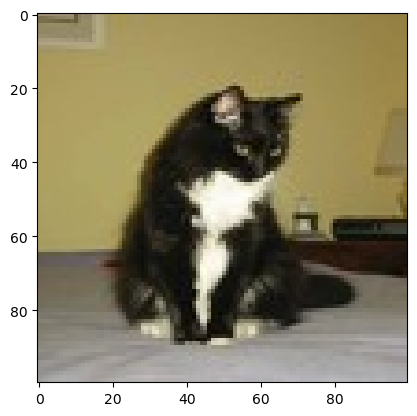

1/1 [==============================] - 0s 144ms/step
Our model says it is a : dog


In [11]:
idx2 = random.randint(0, len(Y_test))
plt.imshow(X_test[idx2, :])
plt.show()

y_pred = model.predict(X_test[idx2, :].reshape(1, 100, 100, 3))
y_pred = y_pred > 0.5

if(y_pred == 0):
    pred = "dog"
else:
    pred = "cat"
print(f"Our model says it is a : {pred}")